pip install transformers datasets sentence_transformers  pillow faiss-gpu-cu12 matplotlib tqdm pandas
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

In [ ]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from datasets import load_dataset
from tqdm import tqdm
import os

# 200000
ds = load_dataset("google-research-datasets/conceptual_captions", split="train")
ds = ds.select(range(200000))
print(ds[0].keys())
print(ds[0])


dict_keys(['image_url', 'caption'])
{'image_url': 'http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/AAAAAAAAM6o/_11MuAAKalQ/IMG_3422.JPG?imgmax=800', 'caption': 'a very typical bus station'}


In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

import faiss

os.makedirs("images", exist_ok=True)

def download_image(idx_example):
    i, example = idx_example
    url = example["image_url"]
    caption = example["caption"]
    try:
        response = requests.get(url, timeout=3) 
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img_path = f"images_1/{i}.jpg"
        img.save(img_path)
        return {"image_path": img_path, "caption": caption}
    except Exception:
        return None

tasks = list(enumerate(ds))

data = []
with ThreadPoolExecutor(max_workers=24) as executor:
    results = list(tqdm(executor.map(download_image, tasks), total=len(tasks)))

data = [r for r in results if r is not None]

Устал ждать .. 258m 46s


dict_keys(['image_url', 'caption'])
{'image_url': 'http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/AAAAAAAAM6o/_11MuAAKalQ/IMG_3422.JPG?imgmax=800', 'caption': 'a very typical bus station'}
  0%|          | 20/200000 [00:32<16:23:42,  2.95s/it]/home/mike/multimodal_image_search/venv/lib/python3.12/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 72%|███████▏  | 14439/200000 [4:18:45<1:39:38,  1.08s/it] 

In [5]:
# Сохраняем метаданные
df = pd.DataFrame(data)
df.to_csv("metadata.csv", index=False)

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
import numpy as np
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_image_embedding(image_path):
    try:
        image = Image.open(image_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model.get_image_features(**inputs)
            
            if hasattr(outputs, 'image_embeds'): 
                image_features = outputs.image_embeds
            elif hasattr(outputs, 'pooler_output'): 
                image_features = outputs.pooler_output
            else:
                image_features = outputs
            
            # 2. Normalize the tensor
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            
        return image_features.cpu().numpy().flatten()
    
    except Exception as e:
        print(f"Ошибка при обработке {image_path}: {e}")
        return None

image_embeddings = []
for img_path in tqdm(df["image_path"]):
    emb = get_image_embedding(img_path)
    image_embeddings.append(emb)

image_embeddings = np.stack(image_embeddings)  # (N, 512)
np.save("image_embeddings.npy", image_embeddings)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 17250.88it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 8838/8838 [05:26<00:00, 27.10it/s]


In [ ]:
dim = image_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)  # косинусное сходство для нормализованных векторов
index.add(image_embeddings.astype(np.float32))
faiss.write_index(index, "image_index.faiss")

In [ ]:
def search(query, k=5):
    inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = model.get_text_features(**inputs)
    
        if hasattr(outputs, 'text_embeds'): 
                text_embedding = outputs.image_embeds
        elif hasattr(outputs, 'pooler_output'):
                text_embedding = outputs.pooler_output
        else:
                text_embedding = outputs # It's already a tensor
    text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
    text_embedding = text_embedding.cpu().numpy().astype(np.float32)

    distances, indices = index.search(text_embedding, k)
    return indices[0], distances[0]


In [22]:
query = "dog on beach"
top_k_indices, scores = search(query, k=5)
for idx, score in zip(top_k_indices, scores):
    print(f"Score: {score:.4f} - {df.iloc[idx]['image_path']}")

Score: 0.3023 - images/5945.jpg
Score: 0.3016 - images/6889.jpg
Score: 0.2967 - images/2187.jpg
Score: 0.2951 - images/13674.jpg
Score: 0.2857 - images/2549.jpg


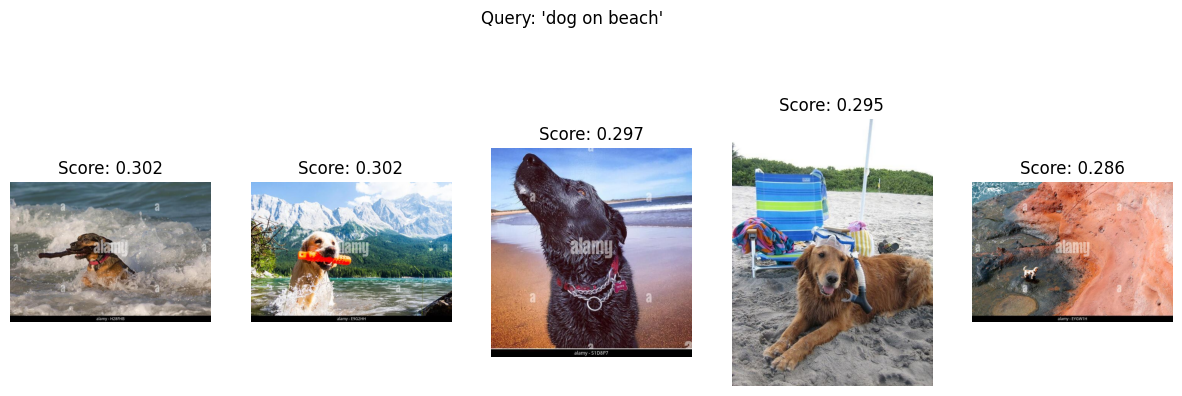

In [ ]:
def show_results(query, k=5):
    indices, scores = search(query, k)
    fig, axes = plt.subplots(1, k, figsize=(15, 5))
    for i, (idx, score) in enumerate(zip(indices, scores)):
        img_path = df.iloc[idx]["image_path"]
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Score: {score:.3f}")
        axes[i].axis("off")
    plt.suptitle(f"Query: '{query}'")
    plt.show()

show_results("dog on beach")

In [ ]:
df = pd.read_csv("metadata.csv")  
image_embeddings = np.load("image_embeddings.npy")
print(f"Загружено {len(df)} изображений, размер эмбеддингов: {image_embeddings.shape}")

# Выбираем подмножество для 
eval_size = min(1000, len(df))
eval_indices = list(range(eval_size))  

# Подготовка списка запросов и соответствующих индексов правильных ответов
queries = df.iloc[eval_indices]['caption'].tolist()
correct_indices = list(range(eval_size))  # для выбранных индексов, правильный ответ - тот же индекс

Загружено 8838 изображений, размер эмбеддингов: (8838, 512)


In [25]:
def evaluate_recall(search_function, queries, correct_indices, k_values=[1, 5, 10]):
    """
    Оценивает recall@k для заданной функции поиска.
    
    search_function: функция, принимающая запрос и возвращающая (indices, scores)
    queries: список строк-запросов
    correct_indices: список правильных индексов для каждого запроса
    k_values: список значений k для оценки
    """
    recalls = {k: [] for k in k_values}
    
    for i, query in enumerate(tqdm(queries, desc="Evaluation")):
        indices, _ = search_function(query, k=max(k_values))
        for k in k_values:
            if correct_indices[i] in indices[:k]:
                recalls[k].append(1)
            else:
                recalls[k].append(0)

    results = {k: np.mean(v) for k, v in recalls.items()}
    return results

In [ ]:
sbert = SentenceTransformer('all-MiniLM-L6-v2')


# Генерация эмбеддингов для всех подписей
print("Генерация эмбеддингов подписей с SentenceTransformer...")
caption_embeddings = []
for caption in tqdm(df['caption']):
    emb = sbert.encode(caption, normalize_embeddings=True)  # нормализация для косинусного сходства
    caption_embeddings.append(emb)
caption_embeddings = np.stack(caption_embeddings).astype(np.float32)

dim = caption_embeddings.shape[1]
sbert_index = faiss.IndexFlatIP(dim)
sbert_index.add(caption_embeddings)
faiss.write_index(sbert_index, "text_index.faiss")
print(f"Индекс подписей построен, размер: {sbert_index.ntotal}")

# поиск 
def sbert_search(query, k=5):
    query_emb = sbert.encode(query, normalize_embeddings=True).astype(np.float32).reshape(1, -1)
    distances, indices = sbert_index.search(query_emb, k)
    return indices[0], distances[0]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 66402.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Генерация эмбеддингов подписей с SentenceTransformer...


100%|██████████| 8838/8838 [00:42<00:00, 208.09it/s]

Индекс подписей построен, размер: 8838


In [ ]:
print("\nОценка CLIP (мультимодальный поиск):")
clip_recalls = evaluate_recall(search, queries, correct_indices, k_values=[1,5,10])
for k, recall in clip_recalls.items():
    print(f"Recall@{k}: {recall:.4f}")



print("\nОценка SentenceTransformer (поиск по подписям):")
sbert_recalls = evaluate_recall(sbert_search, queries, correct_indices, k_values=[1,5,10])
for k, recall in sbert_recalls.items():
    print(f"Recall@{k}: {recall:.4f}")


Оценка CLIP (мультимодальный поиск):


Evaluation: 100%|██████████| 1000/1000 [00:08<00:00, 114.81it/s]


Recall@1: 0.3410
Recall@5: 0.5660
Recall@10: 0.6760

Оценка SentenceTransformer (поиск по подписям):


Evaluation: 100%|██████████| 1000/1000 [00:06<00:00, 157.67it/s]

Recall@1: 0.9880
Recall@5: 0.9970
Recall@10: 1.0000


## CLIP (мультимодальный поиск): Recall@10 = 0.676 означает, что в 67.6% случаев правильное изображение (из той же пары) попадает в топ ## результатов поиска по тексту подписи.  ТО ЕСТЬ НАСКОЛЬКО ТОЧНО CLIP ВОССТАНАВЛИВАЕТ ПОДПИСЬ ПО ЭМБЕДДИНГУ

## SentenceTransformer (поиск по подписям): практически идеальный recall, потому что он ищет текст по тексту, а подписи в датасете уникальны.

Визуализация

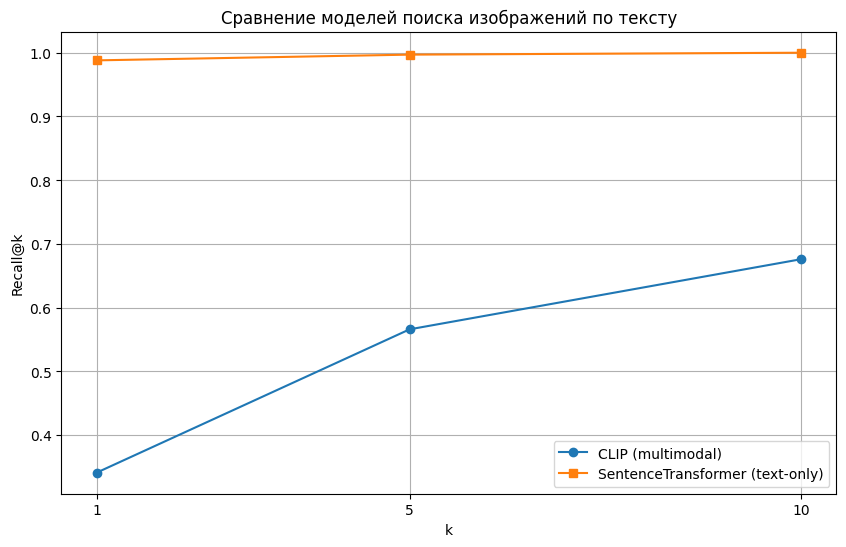

In [29]:
import matplotlib.pyplot as plt

k_values = [1, 5, 10]
clip_scores = [clip_recalls[k] for k in k_values]
sbert_scores = [sbert_recalls[k] for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, clip_scores, marker='o', label='CLIP (multimodal)')
plt.plot(k_values, sbert_scores, marker='s', label='SentenceTransformer (text-only)')
plt.xlabel('k')
plt.ylabel('Recall@k')
plt.title('Сравнение моделей поиска изображений по тексту')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()